In [1]:
import os
os.chdir('./stat_csv')

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
# Load your time series data
orig_df = pd.read_excel('exchange_rates_filtered.xlsx')
orig_df.head()

,DataSeries,US Dollar,Sterling Pound,Swiss Franc,Japanese Yen
0,2025Nov,1.3031,1.7113,1.6211,0.8403
1,2025Oct,1.2952,1.7311,1.6240,0.8560
2,2025Sep,1.2847,1.7351,1.6124,0.8688
3,2025Aug,1.2856,1.7275,1.5938,0.8705
4,2025Jul,1.2809,1.7307,1.6055,0.8723


In [4]:
orig_df.dtypes

DataSeries         object
US Dollar         float64
Sterling Pound    float64
Swiss Franc       float64
Japanese Yen      float64
dtype: object

#### String Time Format Code List: https://strftime.org/

In [5]:
df = orig_df.copy()
df['DataSeries'] = pd.to_datetime(df['DataSeries'], format='%Y%b')  # Match format according to the data pattern
df = df.sort_values(by="DataSeries")
df = df.set_index('DataSeries')
df.head()

,US Dollar,Sterling Pound,Swiss Franc,Japanese Yen
DataSeries,,,,
1990-01-01,1.8895,3.1134,1.2435,1.3015
1990-02-01,1.8637,3.1585,1.2517,1.2808
1990-03-01,1.8774,3.0511,1.2421,1.2266
1990-04-01,1.8785,3.0741,1.2626,1.1851
1990-05-01,1.8570,3.1170,1.3088,1.2089


In [6]:
df.tail()

,US Dollar,Sterling Pound,Swiss Franc,Japanese Yen
DataSeries,,,,
2025-07-01,1.2809,1.7307,1.6055,0.8723
2025-08-01,1.2856,1.7275,1.5938,0.8705
2025-09-01,1.2847,1.7351,1.6124,0.8688
2025-10-01,1.2952,1.7311,1.6240,0.8560
2025-11-01,1.3031,1.7113,1.6211,0.8403


Index(['US Dollar', 'Sterling Pound', 'Swiss Franc', 'Japanese Yen'], dtype='object')


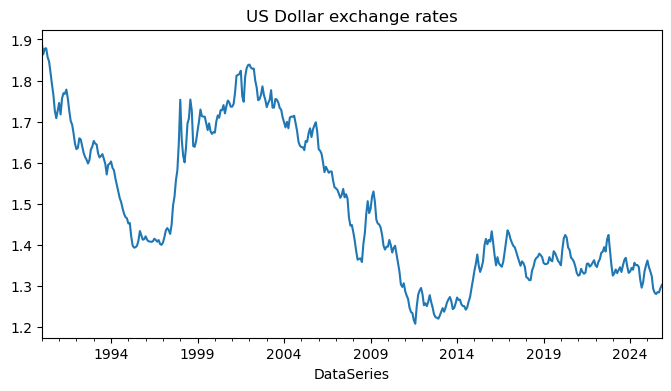

In [7]:
print(df.columns)
value_var = 'US Dollar'
df[value_var].plot(title="US Dollar exchange rates", figsize=(8,4))
plt.show()

### Data Processing

In [8]:
# Detecting and removing outliers using Z-score
from scipy.stats import zscore
z_scores = zscore(df[value_var])
abs_z_scores = np.abs(z_scores)

zscore_threshold = 3 #any data above mean +/- (this_threshold)*sd is considered outliers
outliers = (abs_z_scores > zscore_threshold)  # Z-score threshold.
df = df.loc[~outliers].copy()

print(orig_df.shape)
print(df.shape)

df.head()

(431, 5)
(431, 4)


,US Dollar,Sterling Pound,Swiss Franc,Japanese Yen
DataSeries,,,,
1990-01-01,1.8895,3.1134,1.2435,1.3015
1990-02-01,1.8637,3.1585,1.2517,1.2808
1990-03-01,1.8774,3.0511,1.2421,1.2266
1990-04-01,1.8785,3.0741,1.2626,1.1851
1990-05-01,1.8570,3.1170,1.3088,1.2089


In [9]:
train = df.loc[df.index <= '2023-12-01']
test = df.loc[df.index > '2023-12-01']
forecast_steps = len(test)
train

,US Dollar,Sterling Pound,Swiss Franc,Japanese Yen
DataSeries,,,,
1990-01-01,1.8895,3.1134,1.2435,1.3015
1990-02-01,1.8637,3.1585,1.2517,1.2808
1990-03-01,1.8774,3.0511,1.2421,1.2266
1990-04-01,1.8785,3.0741,1.2626,1.1851
1990-05-01,1.8570,3.1170,1.3088,1.2089
...,...,...,...,...
2023-08-01,1.3505,1.7162,1.5379,0.9324
2023-09-01,1.3638,1.6904,1.5177,0.9230
2023-10-01,1.3690,1.6664,1.5147,0.9156


### Decomposition

<Figure size 2000x800 with 0 Axes>

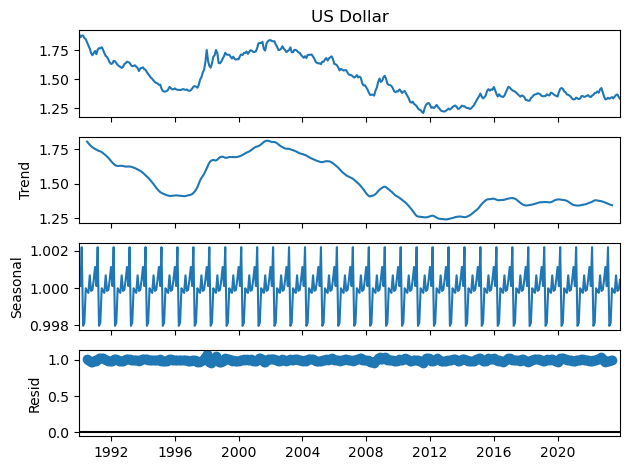

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(train[value_var], model='multiplicative')
fig = plt.figure(figsize=(20,8))  
decomposition.plot()  
plt.show()

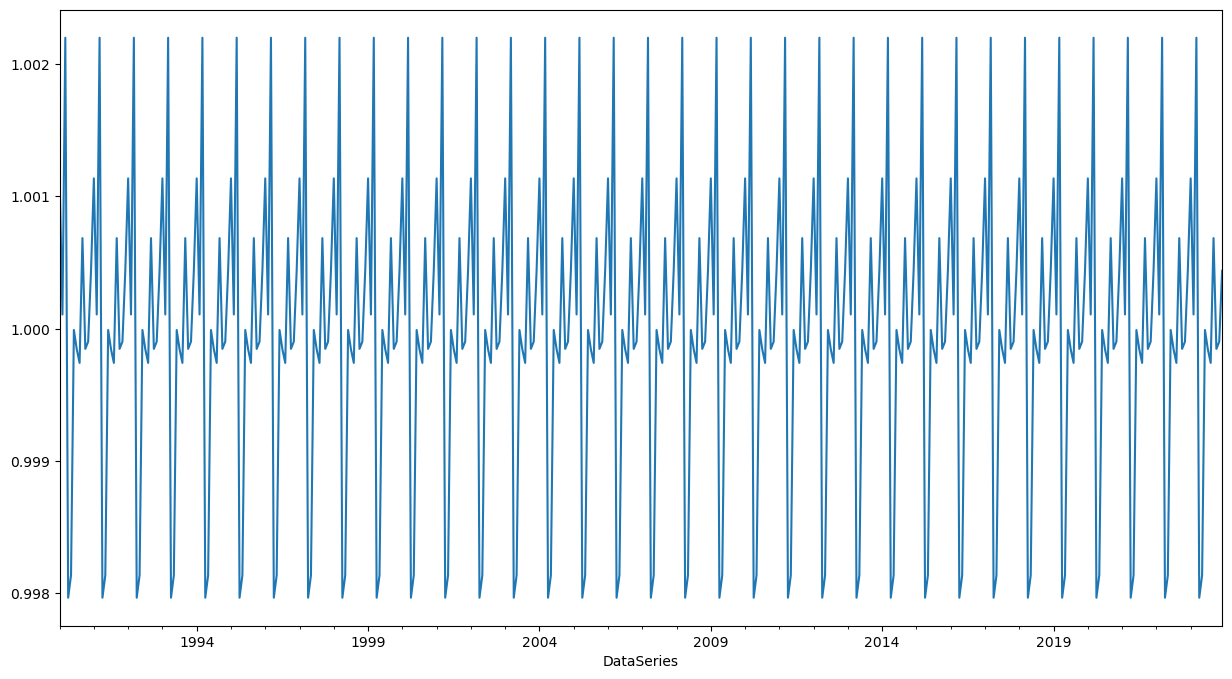

In [11]:
fig = plt.figure(figsize=(15,8))  
decomposition.seasonal.plot()
plt.show()

In [12]:
# Set selected_s for ARIMA model
selected_s = 12

### Find differencing d

In [13]:
from statsmodels.tsa.stattools import adfuller # ADF test
result = adfuller(train[value_var])
result

(np.float64(-2.071368666120966),
 np.float64(0.2561821249232979),
 2,
 405,
 {'1%': np.float64(-3.446599953548936),
  '5%': np.float64(-2.86870295908671),
  '10%': np.float64(-2.570585643956714)},
 np.float64(-1993.814978113288))

In [14]:
def test_adfuller(series, alpha=0.05):
    from statsmodels.tsa.stattools import adfuller
    result = adfuller(series)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    for key, value in result[4].items():
        print(f"Critical Value ({key}): {value}")
    if result[1] <= alpha:
        print("Reject the null hypothesis. Data is stationary")
    else:
        print("Do not reject the null hypothesis. Data is not stationary ")

In [15]:
test_adfuller(train[value_var])

ADF Statistic: -2.071368666120966
p-value: 0.2561821249232979
Critical Value (1%): -3.446599953548936
Critical Value (5%): -2.86870295908671
Critical Value (10%): -2.570585643956714
Do not reject the null hypothesis. Data is not stationary 


In [16]:
train['first_difference'] = (train[value_var] - train[value_var].shift(1)).dropna()
# or you can use df[value_var].diff().dropna()  # diff() = compute difference between t and t-1
train['first_difference'].head()

/tmp/ipykernel_34054/3737312422.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['first_difference'] = (train[value_var] - train[value_var].shift(1)).dropna()


DataSeries
1990-01-01       NaN
1990-02-01   -0.0258
1990-03-01    0.0137
1990-04-01    0.0011
1990-05-01   -0.0215
Name: first_difference, dtype: float64

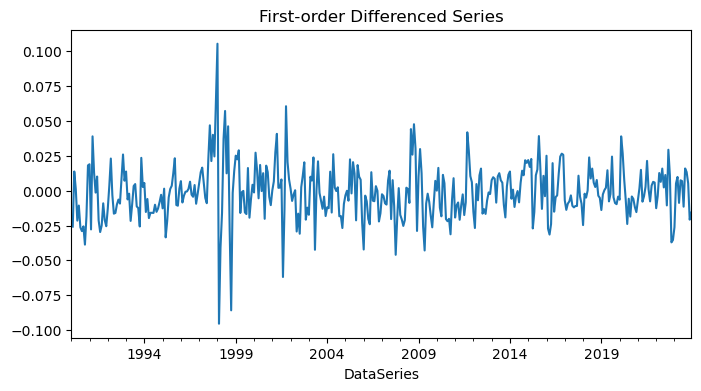

In [17]:
train['first_difference'].plot(title="First-order Differenced Series", figsize=(8,4))
plt.show()

In [18]:
test_adfuller(train['first_difference'].dropna())

ADF Statistic: -13.274640906250461
p-value: 7.9105425753550065e-25
Critical Value (1%): -3.446599953548936
Critical Value (5%): -2.86870295908671
Critical Value (10%): -2.570585643956714
Reject the null hypothesis. Data is stationary


In [19]:
# Set selected_d for ARIMA/SARIMA model
selected_d = 1

### Find differencing D for seasonal timeseries 

In [20]:
# Skip this section if timeseries is not seasonal

/tmp/ipykernel_34054/3786875280.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['seasonal_difference'] = train[value_var] - train[value_var].shift(selected_s)


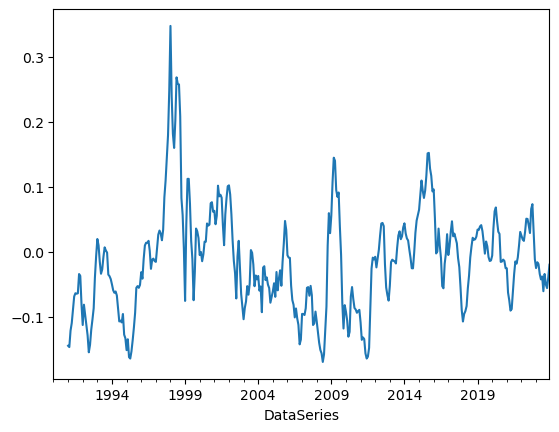

In [21]:
train['seasonal_difference'] = train[value_var] - train[value_var].shift(selected_s)
train['seasonal_difference'].plot()
plt.show()

In [22]:
test_adfuller(train['seasonal_difference'].dropna())

ADF Statistic: -3.3714806911971302
p-value: 0.011970374701766406
Critical Value (1%): -3.4477686860685
Critical Value (5%): -2.869216670067509
Critical Value (10%): -2.570859500573892
Reject the null hypothesis. Data is stationary


In [23]:
# Set selected_D for SARIMA model
selected_D = 1

### Identify p and q from PACF and ACF

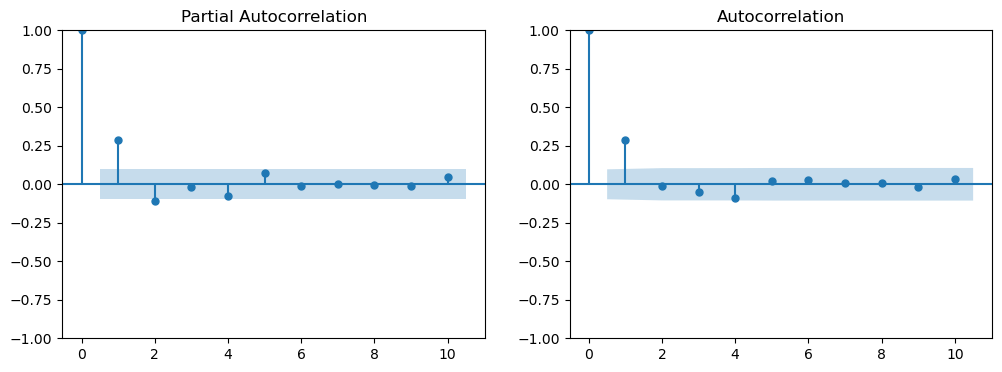

In [24]:
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

fig, ax = plt.subplots(1, 2, figsize=(12,4))

plot_pacf(train['first_difference'].dropna(), lags=10, ax=ax[0])
plot_acf(train['first_difference'].dropna(), lags=10, ax=ax[1])

plt.show()

In [25]:
# Set possible selected_p and selected_q for ARIMA/SARIMA model
# the blue area is the confidental region
selected_p = 2
selected_q = 1 # 0, 1 but 0 is itself

### Identify P and Q from PACF and ACF for seasonal timeseries

In [26]:
# Skip this section if timeseries is not seasonal

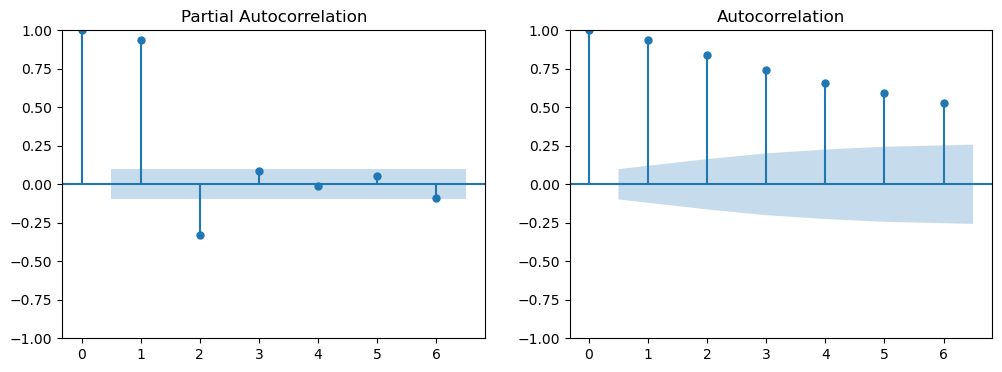

In [27]:
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

fig, ax = plt.subplots(1, 2, figsize=(12,4))

plot_pacf(train['seasonal_difference'].dropna(), lags=6, ax=ax[0])
plot_acf(train['seasonal_difference'].dropna(), lags=6, ax=ax[1])

plt.show()

In [28]:
# Set possible selected_P and selected_Q for SARIMA model
selected_P = 3
selected_Q = 0

### Select SARIMA model based on AIC and BIC

In [29]:
# Set frequeuncy of time index 
# Frequenct String: https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases
train.index = pd.DatetimeIndex(train.index, freq='MS')
train.index.inferred_freq

'MS'

In [30]:
print(selected_s, selected_d, selected_D)
print(selected_p, selected_q)
print(selected_P, selected_Q)

12 1 1
2 1
3 0


In [31]:
# Create all possible choices for p and q
start_p = 0
end_p = 2
start_q = 0
end_q = 1
start_P = 0
end_P = 3
start_Q = 0
end_Q = 0

pdq_choices = []
for pi in range(start_p, end_p+1):
    for qi in range(start_q, end_q+1):
        for Pi in range(start_P, end_P+1):
            for Qi in range(start_Q, end_Q+1):
                pdq_choice = (pi, selected_d, qi)
                PDQ_choice = (Pi, selected_D, Qi, selected_s)
                
                pdq_choices.append([pdq_choice, PDQ_choice])
print(pdq_choices)

[[(0, 1, 0), (0, 1, 0, 12)], [(0, 1, 0), (1, 1, 0, 12)], [(0, 1, 0), (2, 1, 0, 12)], [(0, 1, 0), (3, 1, 0, 12)], [(0, 1, 1), (0, 1, 0, 12)], [(0, 1, 1), (1, 1, 0, 12)], [(0, 1, 1), (2, 1, 0, 12)], [(0, 1, 1), (3, 1, 0, 12)], [(1, 1, 0), (0, 1, 0, 12)], [(1, 1, 0), (1, 1, 0, 12)], [(1, 1, 0), (2, 1, 0, 12)], [(1, 1, 0), (3, 1, 0, 12)], [(1, 1, 1), (0, 1, 0, 12)], [(1, 1, 1), (1, 1, 0, 12)], [(1, 1, 1), (2, 1, 0, 12)], [(1, 1, 1), (3, 1, 0, 12)], [(2, 1, 0), (0, 1, 0, 12)], [(2, 1, 0), (1, 1, 0, 12)], [(2, 1, 0), (2, 1, 0, 12)], [(2, 1, 0), (3, 1, 0, 12)], [(2, 1, 1), (0, 1, 0, 12)], [(2, 1, 1), (1, 1, 0, 12)], [(2, 1, 1), (2, 1, 0, 12)], [(2, 1, 1), (3, 1, 0, 12)]]


In [32]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
# from statsmodels.stats.diagnostic import acorr_ljungbox
# from statsmodels.stats.diagnostic import het_arch
# from statsmodels.stats.stattools import jarque_bera

for pdq_choice in pdq_choices:
    try:
        print(pdq_choice)
        model = SARIMAX(np.log(train[value_var]),order=pdq_choice[0], seasonal_order=pdq_choice[1])
        model_fit = model.fit()
        
        # obtain prob(Q)
        # lb = acorr_ljungbox(model_fit.resid, lags=[10], return_df=True)
        # prob_Q = lb['lb_pvalue'].iloc[0]
        # obtain prob(H)
        # prob_H = het_arch(model_fit.resid)[1]
        # obtain prob(JB)
        # jb_stat, prob_JB, skew, kurt = jarque_bera(model_fit.resid)

        # obtain prob(Q), prob(H), prob(JB)
        prob_Q = model_fit.test_serial_correlation(method='ljungbox')[0][1][0]
        prob_H = model_fit.test_heteroskedasticity(method='breakvar')[0][1]
        prob_JB = model_fit.test_normality(method='jarquebera')[0][1]
    
        print(pdq_choice, ", AIC:", model_fit.aic, ", Prob(Q):", prob_Q, ", Prob(H):", prob_H)
        print(model_fit.pvalues)
    except:
        continue

#===============================
# ar.L1: Strength of dependence on previous value
#        p-value < 0.05 -> AR term is statistically significant
#                        If insignificant → AR term may be unnecessary
# ma.L1: Captures shock/error correction
#        p-value < 0.05 → MA term contributes meaningfully
#                        If insignificant → MA term may be unnecessary#
# sigma² (noise variance): Variance of residuals
#        Smaller = model explains more structure
#===============================
# Ljung–Box: Test whether residuals are white noise
#            H0: residuals are uncorrelated
#            If p-value (Prob(Q)) > 0.05 -> residuals ≈ white noise -> ARIMA remove all temporal structure
# Heteroskedasticity (H): Test  whether variance of residuals is constant
#                         If p-value (Prob(H)) > 0.05 -> contant variance 
# Jarque-Bera (JB): Test whether residuals are normality
#                   If p-value (Prob(JB)) > 0.05 -> residuals roughly normal
#===============================

[(0, 1, 0), (0, 1, 0, 12)]
[(0, 1, 0), (0, 1, 0, 12)] , AIC: -2057.7344750750876 , Prob(Q): 2.461835395507338e-11 , Prob(H): 0.00016905750979869704
sigma2    9.070345e-86
dtype: float64
[(0, 1, 0), (1, 1, 0, 12)]


/nix/store/lvk9lnrkgsp34niv9916v1m2is60s9si-devenv-profile/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


[(0, 1, 0), (1, 1, 0, 12)] , AIC: -2160.363678517695 , Prob(Q): 1.3680598866236059e-10 , Prob(H): 0.00017477325968973435
ar.S.L12    1.276026e-42
sigma2      2.385494e-75
dtype: float64
[(0, 1, 0), (2, 1, 0, 12)]
[(0, 1, 0), (2, 1, 0, 12)] , AIC: -2205.336514206319 , Prob(Q): 3.8567097200406104e-09 , Prob(H): 7.109577654997546e-05
ar.S.L12    6.521438e-59
ar.S.L24    8.982715e-20
sigma2      6.583708e-80
dtype: float64
[(0, 1, 0), (3, 1, 0, 12)]


/nix/store/lvk9lnrkgsp34niv9916v1m2is60s9si-devenv-profile/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


[(0, 1, 0), (3, 1, 0, 12)] , AIC: -2219.213548649058 , Prob(Q): 2.4072720066911735e-10 , Prob(H): 0.000189094186738786
ar.S.L12    8.055402e-58
ar.S.L24    6.894568e-21
ar.S.L36    1.265038e-05
sigma2      2.282216e-76
dtype: float64
[(0, 1, 1), (0, 1, 0, 12)]
[(0, 1, 1), (0, 1, 0, 12)] , AIC: -2110.2214676301533 , Prob(Q): 0.913620379390841 , Prob(H): 7.707850299393239e-05
ma.L1      3.019651e-21
sigma2    1.071216e-110
dtype: float64
[(0, 1, 1), (1, 1, 0, 12)]
[(0, 1, 1), (1, 1, 0, 12)] , AIC: -2208.4161766491166 , Prob(Q): 0.8204469238174326 , Prob(H): 1.3180919602887238e-05
ma.L1       6.322704e-23
ar.S.L12    3.789998e-61
sigma2      1.452486e-91
dtype: float64
[(0, 1, 1), (2, 1, 0, 12)]
[(0, 1, 1), (2, 1, 0, 12)] , AIC: -2245.165002966811 , Prob(Q): 0.883859687880695 , Prob(H): 1.0136472543159007e-05
ma.L1       3.740225e-20
ar.S.L12    5.671282e-64
ar.S.L24    2.122314e-14
sigma2      1.829123e-97
dtype: float64
[(0, 1, 1), (3, 1, 0, 12)]
[(0, 1, 1), (3, 1, 0, 12)] , AIC: -2266.

/nix/store/lvk9lnrkgsp34niv9916v1m2is60s9si-devenv-profile/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


[(1, 1, 0), (1, 1, 0, 12)] , AIC: -2201.4734857486014 , Prob(Q): 0.5061862697155575 , Prob(H): 1.0677825301297549e-05
ar.L1       3.562846e-23
ar.S.L12    9.144606e-63
sigma2      2.442440e-86
dtype: float64
[(1, 1, 0), (2, 1, 0, 12)]
[(1, 1, 0), (2, 1, 0, 12)] , AIC: -2239.9053363318258 , Prob(Q): 0.47490263380000386 , Prob(H): 7.5064796664351706e-06
ar.L1       3.944650e-20
ar.S.L12    4.025331e-67
ar.S.L24    3.424336e-16
sigma2      2.218858e-91
dtype: float64
[(1, 1, 0), (3, 1, 0, 12)]
[(1, 1, 0), (3, 1, 0, 12)] , AIC: -2260.4218077236583 , Prob(Q): 0.3834035591736914 , Prob(H): 2.434900486419846e-05
ar.L1       4.665022e-23
ar.S.L12    2.108382e-68
ar.S.L24    1.176605e-21
ar.S.L36    3.382342e-07
sigma2      1.527340e-88
dtype: float64
[(1, 1, 1), (0, 1, 0, 12)]
[(1, 1, 1), (0, 1, 0, 12)] , AIC: -2108.1077602280893 , Prob(Q): 0.9151196083206032 , Prob(H): 6.93758961506387e-05
ar.L1     7.159102e-01
ma.L1     2.328351e-03
sigma2    1.112755e-93
dtype: float64
[(1, 1, 1), (1, 1, 0

[(2, 1, 0), (3, 1, 0, 12)] , RMSE: 0.035938924913207604 , MAE : 0.02897146492562628


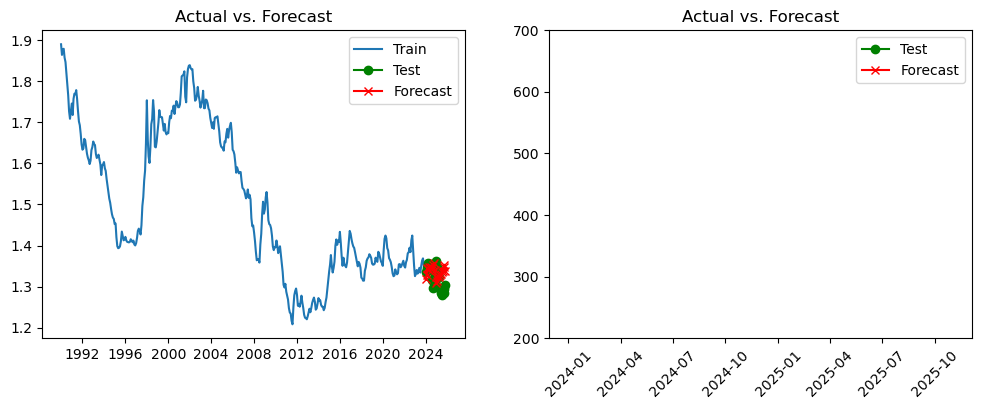

In [33]:
pdq_choice = [(2, 1, 0), (3, 1, 0, 12)]

model = SARIMAX(np.log(train[value_var]),order=pdq_choice[0], seasonal_order=pdq_choice[1])
model_fit = model.fit()
log_forecast = model_fit.forecast(steps=forecast_steps)

# aligne index
forecast = np.exp(log_forecast)
forecast.index = test.index

from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = np.sqrt(mean_squared_error(test[value_var], forecast))
mae = mean_absolute_error(test[value_var], forecast)

print(pdq_choice, ", RMSE:", rmse, ", MAE :", mae)

fig, ax = plt.subplots(1, 2, figsize=(12,4))

ax[0].plot(train[value_var], label="Train")
ax[0].plot(test[value_var], label="Test", marker="o", color='green')
ax[0].plot(test.index, forecast, label="Forecast", marker="x", color='red')
ax[0].legend()
ax[0].set_title("Actual vs. Forecast")

ax[1].plot(test[value_var], label="Test", marker="o", color='green')
ax[1].plot(test.index, forecast, label="Forecast", marker="x", color='red')
ax[1].legend()
ax[1].set_title("Actual vs. Forecast")
ax[1].tick_params(axis='x', labelrotation=45)
ax[1].set_ylim([200, 700])
    
plt.show()

In [34]:
pdq_choice = [(2, 1, 0), (3, 1, 0, 12)]

model = SARIMAX(np.log(train[value_var]),order=pdq_choice[0], seasonal_order=pdq_choice[1])
model_fit = model.fit()
log_forecast = model_fit.forecast(steps=forecast_steps)
forecast = np.exp(log_forecast)
print(model_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                          US Dollar   No. Observations:                  408
Model:             SARIMAX(2, 1, 0)x(3, 1, 0, 12)   Log Likelihood                1138.513
Date:                            Thu, 19 Feb 2026   AIC                          -2265.026
Time:                                    21:54:24   BIC                          -2241.153
Sample:                                01-01-1990   HQIC                         -2255.568
                                     - 12-01-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3681      0.040      9.314      0.000       0.291       0.446
ar.L2         -0.1278      0.047   

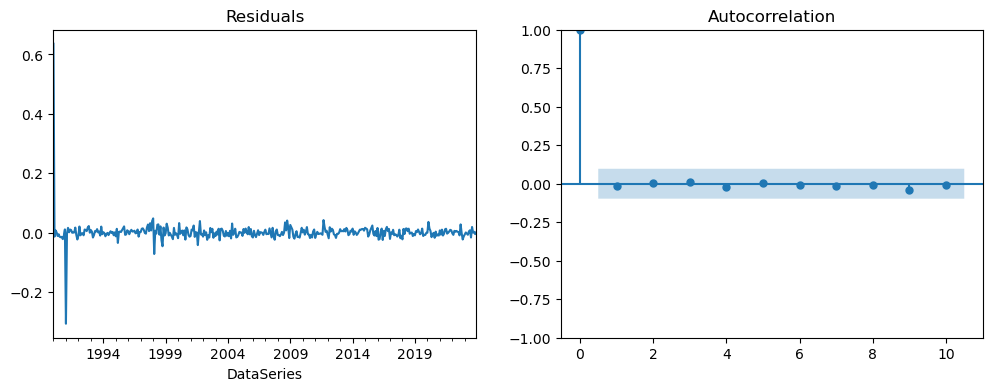

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))

residuals = model_fit.resid
residuals.plot(title="Residuals", ax=ax[0])
plot_acf(residuals, lags=10, ax=ax[1])
plt.show()

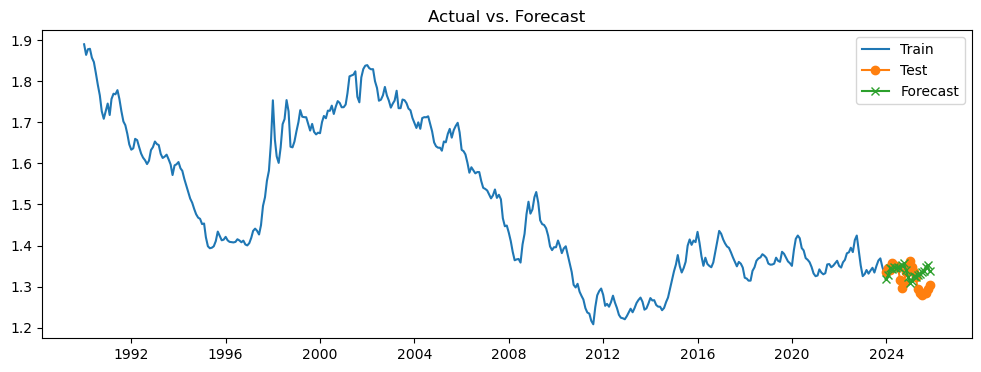

In [36]:
plt.figure(figsize=(12,4))
plt.plot(train[value_var], label="Train")
plt.plot(test[value_var], label="Test", marker="o")
plt.plot(test.index, forecast, label="Forecast", marker="x")
plt.legend()
plt.title("Actual vs. Forecast")
plt.savefig("../src/forecast_SARIMA.jpg")
plt.show()

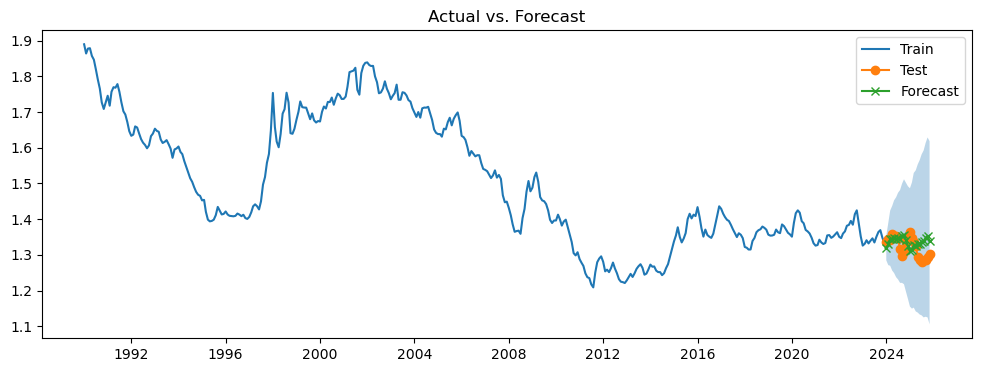

In [37]:
# Plot with confidence intervals of forecasting values

plt.figure(figsize=(12,4))

# Confidence intervals
model_forecast = model_fit.get_forecast(steps=forecast_steps)
forecast_mean = np.exp(model_forecast.predicted_mean)           # Predicted values, same result as model_fit.forecast(steps=forecast_steps)
forecast_ci = np.exp(model_forecast.conf_int())

plt.plot(train[value_var], label="Train")
plt.plot(test[value_var], label="Test", marker="o")
plt.plot(forecast_mean, label="Forecast", marker="x")

# Plot confidence intervals
plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.3
)

plt.legend()
plt.title("Actual vs. Forecast")
plt.show()

### Regression with Lags

In [38]:
value_var = 'US Dollar'

In [39]:
def create_lags(data, lags=12):
    df_lag = pd.DataFrame(index=data.index)

    for i in range(1, lags+1):
        df_lag[f'lag_{i}'] = data.shift(i)

    df_lag['y'] = data
    return df_lag.dropna()

data = create_lags(df[value_var], lags=12)
data.head()

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,y
DataSeries,,,,,,,,,,,,,
1991-01-01,1.7265,1.7084,1.7267,1.7654,1.7910,1.8200,1.8463,1.8570,1.8785,1.8774,1.8637,1.8895,1.7454
1991-02-01,1.7454,1.7265,1.7084,1.7267,1.7654,1.7910,1.8200,1.8463,1.8570,1.8785,1.8774,1.8637,1.7176
1991-03-01,1.7176,1.7454,1.7265,1.7084,1.7267,1.7654,1.7910,1.8200,1.8463,1.8570,1.8785,1.8774,1.7565
1991-04-01,1.7565,1.7176,1.7454,1.7265,1.7084,1.7267,1.7654,1.7910,1.8200,1.8463,1.8570,1.8785,1.7693
1991-05-01,1.7693,1.7565,1.7176,1.7454,1.7265,1.7084,1.7267,1.7654,1.7910,1.8200,1.8463,1.8570,1.7679


In [40]:
split = int(len(data)*0.7)

train = data.iloc[:split]
test  = data.iloc[split:]

X_train, y_train = train.drop(columns='y'), train['y']
X_test,  y_test  = test.drop(columns='y'),  test['y']

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [43]:
reg_predictions = model.predict(X_test_scaled)


from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, reg_predictions)
rmse = np.sqrt(mean_squared_error(y_test, reg_predictions))

print("RMSE:", rmse, "MAE:", mae)

RMSE: 0.014137183762976754 MAE: 0.011161599459666643


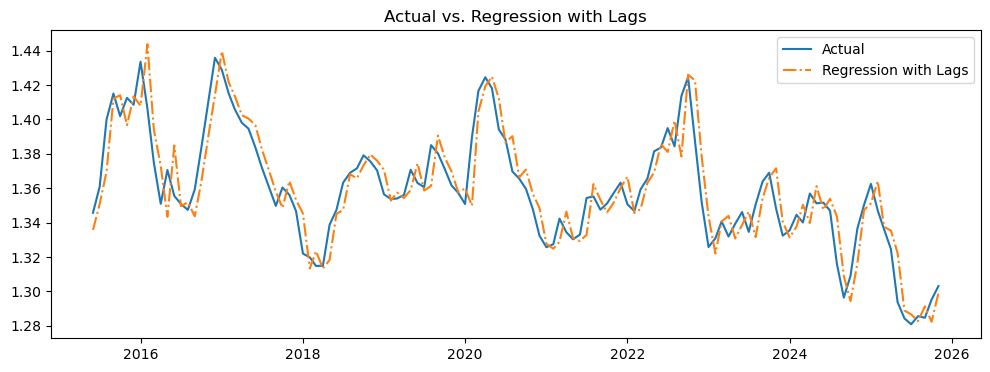

In [44]:
plt.figure(figsize=(12,4))
plt.plot(y_test, label="Actual")
plt.plot(y_test.index, reg_predictions, '-.', label="Regression with Lags")
plt.legend(['Actual', 'Regression with Lags'])
plt.title('Actual vs. Regression with Lags')
plt.show()

### RNN with Lags

In [45]:
from sklearn.preprocessing import StandardScaler

data = df[value_var].values.astype('float32')
data = data.reshape(-1,1)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data).flatten()

In [46]:
def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data)-window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, window=14)

In [47]:
X = X.reshape((X.shape[0], X.shape[1], 1))
split = int(len(X)*0.7)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [48]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

window = 14
rnn = Sequential([
    SimpleRNN(32, activation='tanh', input_shape=(window,1)),
    Dense(1)
])

rnn.compile(optimizer='adam', loss='mse')
rnn.fit(X_train, y_train, epochs=100, verbose=1)

2026-02-19 21:54:25.331786: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Epoch 1/100


/nix/store/lvk9lnrkgsp34niv9916v1m2is60s9si-devenv-profile/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4676  
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0884 
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0571 
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0429 
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0372 
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0328 
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0303 
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0273 
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0254 
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0251 
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0242 
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0224 
Epoch 13/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0217 
Epoch 14/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0212 
Epoch 15/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0211 


In [49]:
rnn_predictions = rnn.predict(X_test)

y_test_inv  = scaler.inverse_transform(y_test.reshape(-1,1))
rnn_predictions_inv  = scaler.inverse_transform(rnn_predictions)

# Evaluation
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test_inv, rnn_predictions_inv))
mae = mean_absolute_error(y_test_inv, rnn_predictions_inv)
print("RMSE:", rmse, ", MAE :", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
RMSE: 0.017119951634256385 , MAE : 0.01389522198587656


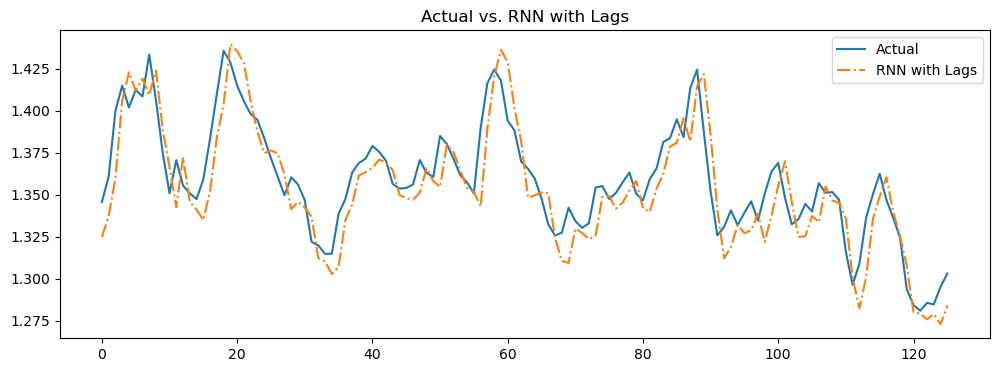

In [50]:
plt.figure(figsize=(12,4))
plt.plot(y_test_inv, label="Actual")
plt.plot(rnn_predictions_inv, '-.', label="RNN with Lags")
plt.legend(['Actual', 'RNN with Lags'])
plt.title('Actual vs. RNN with Lags')
plt.savefig("../src/forecast_RNN_with_lags.jpg")
plt.show()

### LSTM with Lags

In [51]:
from tensorflow.keras.layers import LSTM

lstm = Sequential([
    LSTM(32, activation='tanh', input_shape=(window,1)),
    Dense(1)
])

lstm.compile(optimizer='adam', loss='mse')

lstm.fit(X_train, y_train, epochs=100, verbose=1)

Epoch 1/100


/nix/store/lvk9lnrkgsp34niv9916v1m2is60s9si-devenv-profile/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7329  
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3151 
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1568 
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1118 
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0838 
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0807 
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0756 
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0713 
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0680 
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0652 
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0625 
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0611 
Epoch 13/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0581 
Epoch 14/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0555 
Epoch 15/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0534 


In [52]:
lstm_predictions = lstm.predict(X_test)

y_test_inv  = scaler.inverse_transform(y_test.reshape(-1,1))
lstm_predictions_inv  = scaler.inverse_transform(lstm_predictions)

# Evaluation
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test_inv, lstm_predictions_inv))
mae = mean_absolute_error(y_test_inv, lstm_predictions_inv)
print("RMSE:", rmse, ", MAE :", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
RMSE: 0.017432234090164655 , MAE : 0.01356443203985691


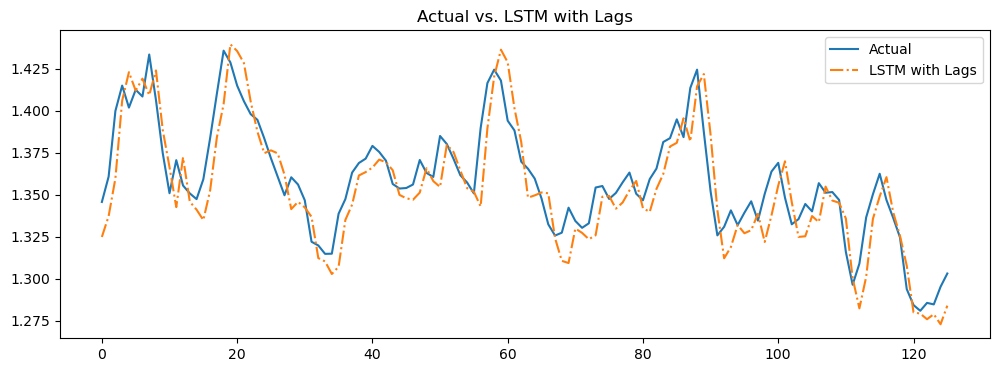

In [53]:
plt.figure(figsize=(12,4))
plt.plot(y_test_inv, label="Actual")
plt.plot(rnn_predictions_inv, '-.', label="LSTM with Lags")
plt.legend(['Actual', 'LSTM with Lags'])
plt.title('Actual vs. LSTM with Lags')
plt.show()

### RNN with features

In [54]:
df.columns

Index(['US Dollar', 'Sterling Pound', 'Swiss Franc', 'Japanese Yen'], dtype='object')

In [55]:
train = df.loc[df.index <= '2023-12-01']
test = df.loc[df.index > '2023-12-01']
forecast_steps = len(test)

FEATURES = ['Sterling Pound', 'Swiss Franc', 'Japanese Yen']
TARGET = 'US Dollar'

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

In [56]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense


# Prepare your time series data (train_x, train_y)
train_x = np.array(X_train)  # input sequences
train_y = np.array(y_train)  # target values

# Reshape the data for RNN
train_x = train_x.reshape((train_x.shape[0], train_x.shape[1], 1))

# Build the RNN model
model = Sequential()
model.add(SimpleRNN(50, activation='relu', input_shape=(train_x.shape[1], 1)))
model.add(Dense(1))

# Compile and fit the model
model.compile(optimizer='adam', loss='mse')
model.fit(train_x, train_y, epochs=20, verbose=1)

Epoch 1/20


/nix/store/lvk9lnrkgsp34niv9916v1m2is60s9si-devenv-profile/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0961  
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0580 
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0507 
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0203 
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0180 
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0158 
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0152 
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0151 
Epoch 9/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0151 
Epoch 10/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0151 
Epoch 11/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0150 
Epoch 12/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0150 
Epoch 13/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0149 
Epoch 14/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0148 
Epoch 15/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0150 
Epoch 16/20
13

In [57]:
# Predict values
test_x = np.array(X_test)  # input sequences
test_y = np.array(y_test)  # target values

predictions = model.predict(test_x)

# Evaluation
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(test_y, predictions))
mae = mean_absolute_error(test_y, predictions)
print("RMSE:", rmse, ", MAE :", mae)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
RMSE: 0.13916738565612796 , MAE : 0.13411150196738864


/tmp/ipykernel_34054/585808477.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['rnn_prediction'] = predictions


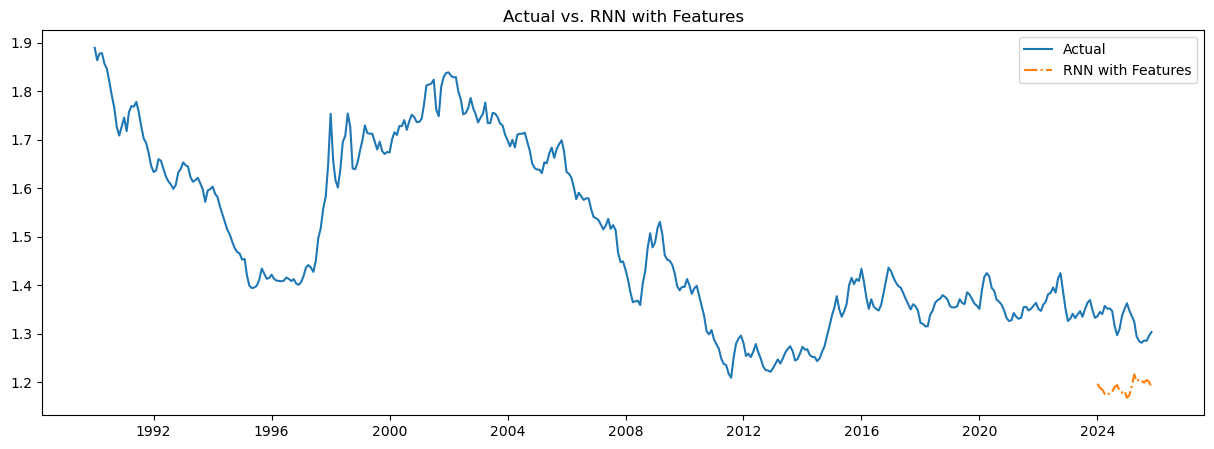

In [58]:
result = df.copy()
test['rnn_prediction'] = predictions
result = result.merge(test['rnn_prediction'], how='left', left_index=True, right_index=True)

plt.figure(figsize=(15,5))
plt.plot(result[[TARGET]])
plt.plot(test['rnn_prediction'], '-.')
plt.legend(['Actual', 'RNN with Features'])
plt.title('Actual vs. RNN with Features')
plt.savefig("../src/forecast_RNN_with_features.jpg")
plt.show()

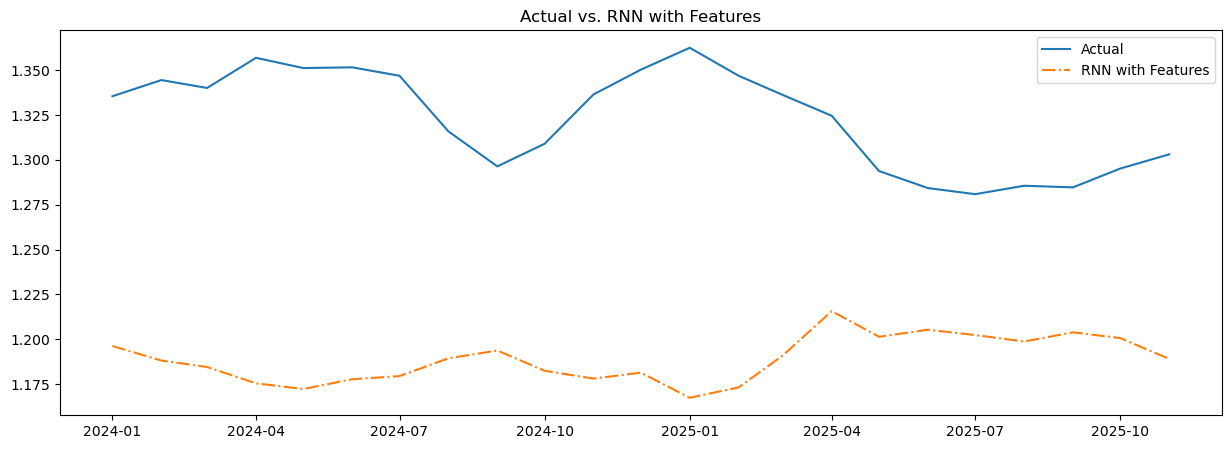

In [59]:
plt.figure(figsize=(15,5))
plt.plot(test[TARGET])
plt.plot(test['rnn_prediction'], '-.', label='RNN with Features')
plt.legend(['Actual', 'RNN with Features'])
plt.title('Actual vs. RNN with Features')
plt.show()

### LSTM with features

In [60]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Reshape for LSTM
train_x = train_x.reshape((train_x.shape[0], train_x.shape[1], 1))

# Build the LSTM model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(train_x.shape[1], 1)))
model.add(Dense(1))

# Compile and fit the model
model.compile(optimizer='adam', loss='mse')
model.fit(train_x, train_y, epochs=20, verbose=1)

Epoch 1/20


/nix/store/lvk9lnrkgsp34niv9916v1m2is60s9si-devenv-profile/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.5119  
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0268 
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5469 
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1404 
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0275 
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0254 
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0177 
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0174 
Epoch 9/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0170 
Epoch 10/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0172 
Epoch 11/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0169 
Epoch 12/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0170 
Epoch 13/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0169 
Epoch 14/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0170 
Epoch 15/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0170 
Epoch 16/20
13

In [61]:
# Predict values
test_x = np.array(X_test)  # input sequences
test_y = np.array(y_test)  # target values

predictions = model.predict(test_x)

# Evaluation
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(test_y, predictions))
mae = mean_absolute_error(test_y, predictions)
print("RMSE:", rmse, ", MAE :", mae)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
RMSE: 0.10027532704486393 , MAE : 0.09150184662860372


/tmp/ipykernel_34054/3405858396.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['lstm_prediction'] = predictions


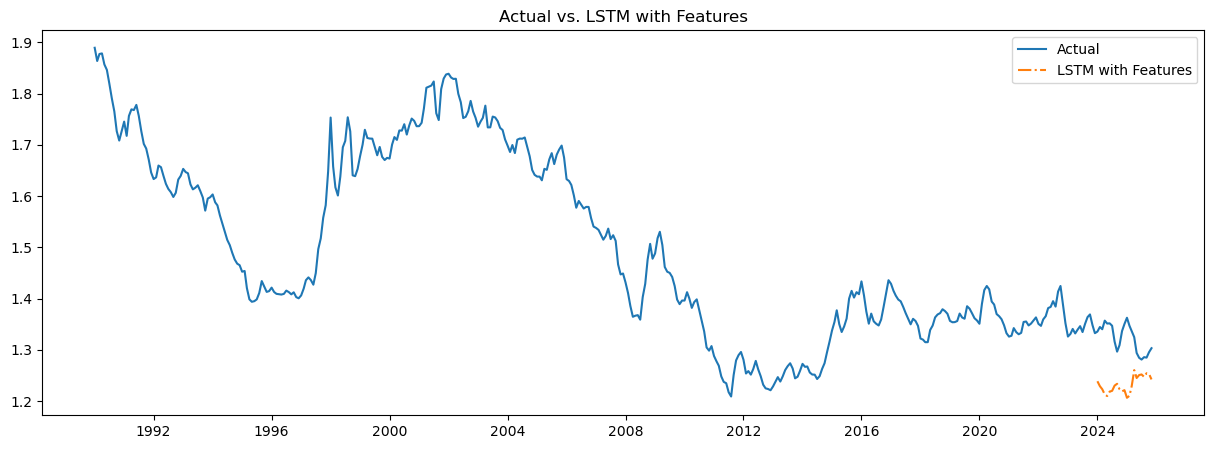

In [62]:
result = df.copy()
test['lstm_prediction'] = predictions
result = result.merge(test['lstm_prediction'], how='left', left_index=True, right_index=True)

plt.figure(figsize=(15,5))
plt.plot(result[[TARGET]])
plt.plot(test['lstm_prediction'], '-.')
plt.legend(['Actual', 'LSTM with Features'])
plt.title('Actual vs. LSTM with Features')
plt.show()

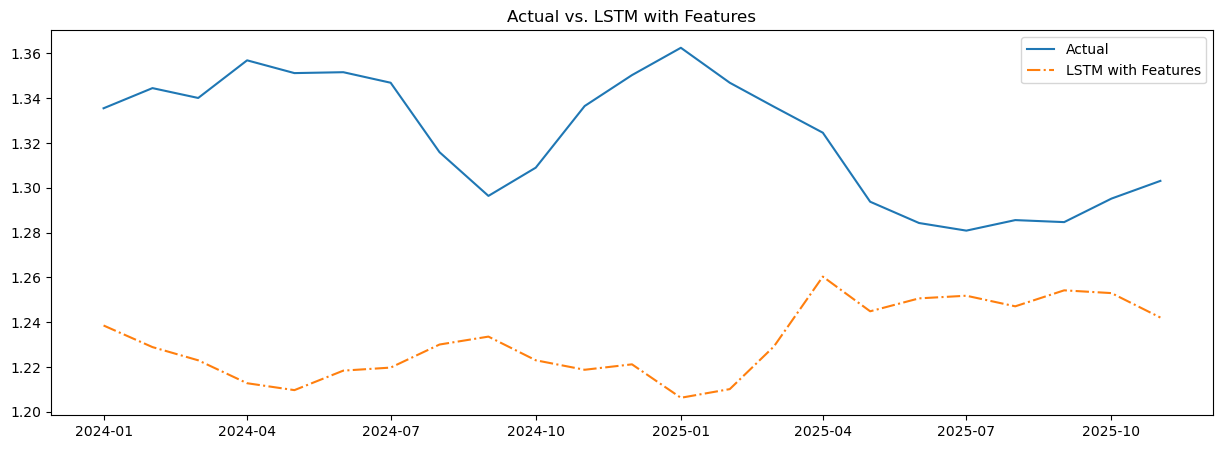

In [63]:
plt.figure(figsize=(15,5))
plt.plot(test[TARGET])
plt.plot(test['lstm_prediction'], '-.')
plt.legend(['Actual', 'LSTM with Features'])
plt.title('Actual vs. LSTM with Features')
plt.show()